### Individual Homework

VIDHYAMINI ROUTHU

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress 

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [40]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


In [41]:
movies.head()

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [42]:
movies_count_by_genre = (
    movies
    .loc[:, ['title']]
    .groupby(movies['genre'])
    .count()
    .sort_values('title', ascending=False)
)
movies_count_by_genre

,title
genre,
Comedy,848
Action,738
Drama,498
Adventure,288
Crime,202
Biography,135
Horror,131
Animation,35
Fantasy,28


**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [43]:
#movies.head()

final_returns = (
    movies
    .assign(
        return_on_budget = movies['gross'] / movies['budget']
    )
    .groupby(['genre'])[["gross", "budget", "return_on_budget"]]
    .mean()
    .sort_values('return_on_budget', ascending=False)
)
final_returns

,gross,budget,return_on_budget
genre,,,
Horror,3.771374e+07,1.350492e+07,88.304785
Biography,4.520181e+07,2.854370e+07,22.280597
Musical,9.208400e+07,3.189500e+06,18.817819
Family,1.491605e+08,1.483333e+07,14.076490
Documentary,1.735397e+07,5.887852e+06,8.698550
Western,2.082188e+07,3.465000e+06,7.062800
Fantasy,4.240884e+07,1.758214e+07,6.681969
Animation,9.843379e+07,6.170143e+07,5.009095
Comedy,4.263055e+07,2.444632e+07,3.713990


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [44]:
movies.head()
director_gross_revenue = (
    movies
    .pivot_table(
        index = 'director',
        values = 'gross',
        aggfunc = ['sum','mean','median','std']
    )
    .sort_values(by=('sum','gross'), ascending=False)
    .head(15)  
)
director_gross_revenue

,sum,mean,median,std
,gross,gross,gross,gross
director,,,,
Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

,mean,min,max,median,std
,rating,rating,rating,rating,rating
genre,,,,,
Action,6.232249,2.1,9.0,6.30,1.030362
Adventure,6.506597,2.3,8.6,6.60,1.093881
Animation,6.651429,4.5,8.0,6.90,0.968131
Biography,7.114074,4.5,8.9,7.20,0.759827
Comedy,6.109670,1.9,8.8,6.20,1.023075
Crime,6.915347,4.8,9.3,6.90,0.849356
Documentary,6.660000,1.6,8.5,7.40,1.766588
Drama,6.731526,2.1,8.8,6.80,0.916993


<Axes: xlabel='rating', ylabel='Density'>

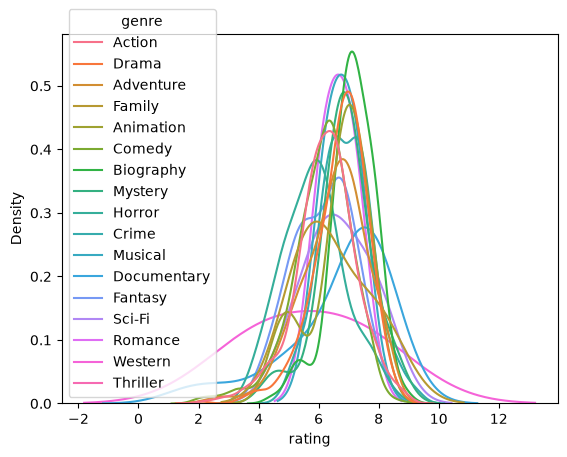

In [45]:
ratings_by_genre = (
    movies.
    pivot_table(
        index = 'genre',
        values = 'rating',
        aggfunc = ['mean','min','max','median','std']
    )
)
display(ratings_by_genre)

#sns.histplot(data = movies, x='rating',hue='genre',bins=10)
sns.kdeplot(data = movies, x = 'rating',hue='genre',common_norm=False,warn_singular=False)


**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

In [46]:
#movies.head()
#what is the count of genres of movies in different years available.

movie_genre_years = (
    movies
    .pivot_table(
        index=['year'],
        columns='genre',
        values= 'title',
        aggfunc= 'count',
        fill_value = 0
    )
)
display(movie_genre_years)

genre,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,Western
year,,,,,,,,,,,,,,,,,
1920,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1929,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1933,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1935,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1936,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012,36,14,2,7,36,7,3,20,0,1,6,0,0,0,0,0,0
2013,32,18,2,8,31,11,2,18,0,2,5,0,0,0,0,0,0
2014,38,14,0,8,27,7,0,15,0,2,6,0,0,0,0,1,0


This will help us to understand what kind of movies were released in the years. Movies generally speak about issues that happen around us or to spread a message.For example: When a war kind of situation happens, it is highly likely movies in that genre pops us and becomes success. Hence this data table helps to find which movies are more to identify trends.

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

LinregressResult(slope=np.float64(752.4409541692246), intercept=np.float64(48764827.631384134), rvalue=np.float64(0.21316094997020546), pvalue=np.float64(9.017742503037235e-32), stderr=np.float64(63.40075940087314), intercept_stderr=np.float64(1520228.4081112018))


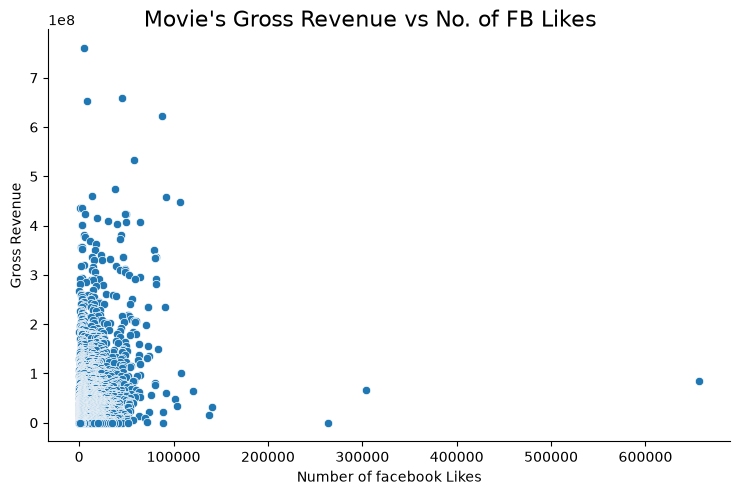

In [47]:
movies.head()
movie_success_metric = sns.relplot(
    data=movies,
    x= 'cast_facebook_likes',
    y='gross',
    kind='scatter',
    height=5,
    aspect=1.5
)
movie_success_metric.set_axis_labels("Number of facebook Likes","Gross Revenue")
movie_success_metric.figure.suptitle("Movie's Gross Revenue vs No. of FB Likes", fontsize=16) 
linear_regression = linregress(movies['cast_facebook_likes'],movies['gross'])
print(linear_regression)

Variable used for Y-axis: gross, X-axis: cast_facebook_likes - Because we are finding is cast_facebook_likes changes gross revenue not other way around
rvalue = 0.2231 : which means weak linear relationship, pvalue = 9.017742503037235e-32 : which is very less <0.05 which means there is statistically evidence that there is relationship.


**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

LinregressResult(slope=np.float64(1.0631610137138425), intercept=np.float64(14905455.365741834), rvalue=np.float64(0.6408341375478341), pvalue=np.float64(0.0), stderr=np.float64(0.02341320073163451), intercept_stderr=np.float64(1396457.1431899515))
Budget is a slightly good predictor but other factors also change this relationship. r-value  = 0.6408341375478341 : which means the relationship is slightly linear relationship. p-value = 0.0 : which means relationship is significant.


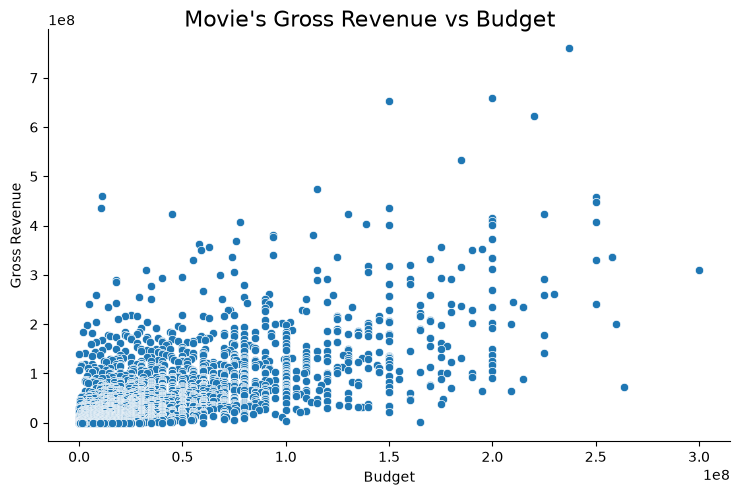

In [48]:
movie_success_metric = sns.relplot(
    data=movies,
    x= 'budget',
    y='gross',
    kind='scatter',
    height=5,
    aspect=1.5
)
movie_success_metric.set_axis_labels("Budget","Gross Revenue")
movie_success_metric.figure.suptitle("Movie's Gross Revenue vs Budget", fontsize=16) 
linear_regression = linregress(movies['budget'],movies['gross'])
print(linear_regression)
print("Budget is a slightly good predictor but other factors also change this relationship. r-value  = 0.6408341375478341 : which means the relationship is slightly linear relationship. p-value = 0.0 : which means relationship is significant.")

Budget is a slightly good predictor but other factors also change this relationship. r-value  = 0.6408341375478341 : which means the relationship is slightly linear relationship. p-value = 0.0 : which means relationship is significant.

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

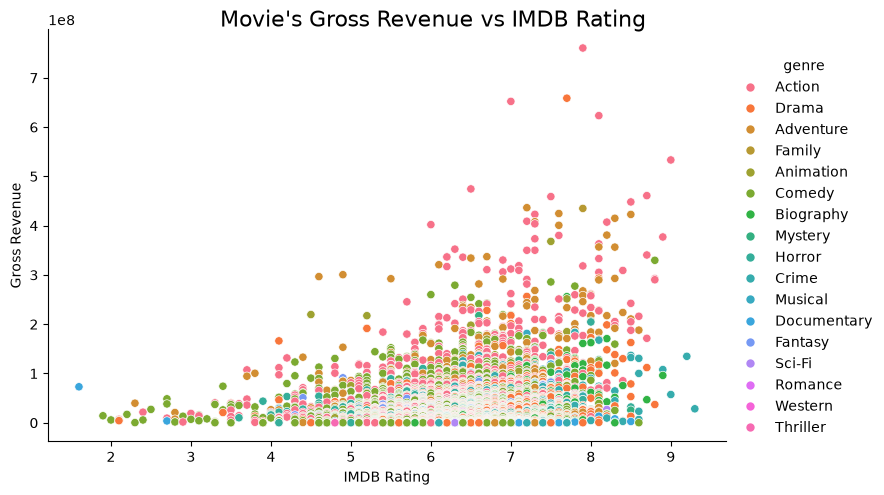

In [49]:
movie_success_metric = sns.relplot(
    data=movies,
    x= 'rating',
    y='gross',
    hue = 'genre',
    kind='scatter',
    height=5,
    aspect=1.5
)
movie_success_metric.set_axis_labels("IMDB Rating","Gross Revenue")
movie_success_metric.figure.suptitle("Movie's Gross Revenue vs IMDB Rating", fontsize=16) 
linear_regression = linregress(movies['rating'],movies['gross'])


Rating is a not good predictor but other factors also change this relationship. r-value  = 0.26942830203612034 : which means the relationship is slightly linear relationship. p-value = 2.0488422291552823e-50 : which is very small value <0.05 means relationship is significant but not strong.
Data is skewed in this dataset with very few movies in high gross revenue and more movies with low gross revenue.

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

Text(0.5, 0.98, "Movie's Year vs Budget")

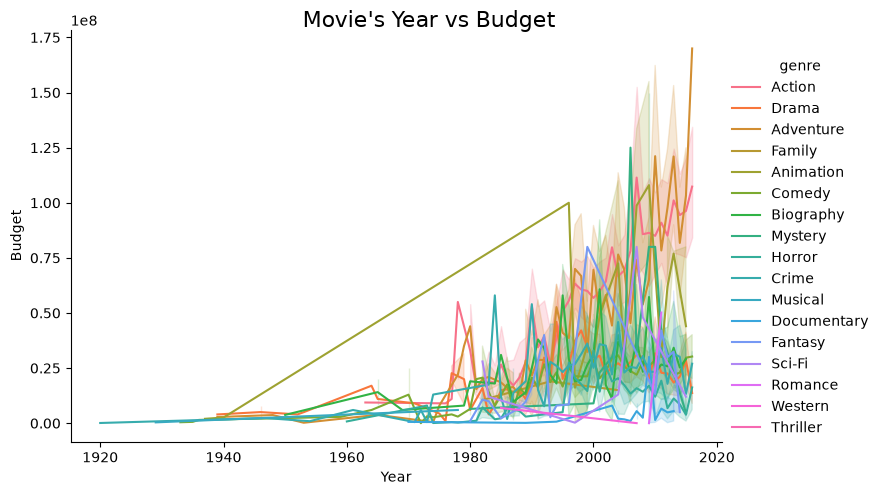

In [50]:
movie_success_metric = sns.relplot(
    data=movies,
    x= 'year',
    y='budget',
    hue = 'genre',
    kind='line',
    height=5,
    aspect=1.5
)
movie_success_metric.set_axis_labels("Year","Budget")
movie_success_metric.figure.suptitle("Movie's Year vs Budget", fontsize=16)

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.